In [33]:
import os
import re
import glob
import matplotlib.pyplot as plt
import numpy as np
import cv2
import h5py
import torch
import torchvision.transforms as T
from PIL import Image
from pathlib import Path
from datetime import datetime

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from PIL import Image as PILImage
import matplotlib.patches as patches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from MirrorExtractor.simple_mirror_extractor import SimpleMirrorExtractor
from MirrorFeatureExtractor.mirror_feature_extractor import MirrorFeatureExtractor

In [45]:
def get_crop_from_img(img_path, smext):
    img_rgb = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    mirror_crop_list = []
    for mirror_id in range(0, 249):
        mirror_crop = smext.extract_mirror(img_rgb, mirror_id=mirror_id)
        mirror_crop_list.append(mirror_crop)
    return mirror_crop_list

def show_img(img_path):
    img_orig = Image.open(img_path).convert("RGB")
    plt.figure()
    plt.imshow(img_orig)
    plt.show()

In [9]:
BASE_DIR = "/home/pgliwny/Praca/Computer_vision_for_MAGIC/data"
ROOT = Path(BASE_DIR) / "data/images_for_analysis"
MIRROR_POINTS_JSON = Path(BASE_DIR) / "points_IRCam.json"
SMExt = SimpleMirrorExtractor(str(MIRROR_POINTS_JSON))

In [10]:
image_paths = glob.glob("/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/*.jpg")
print(len(image_paths))
for p in image_paths[:5]:
    print(p)

141
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251207_081431M.jpg
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251207_083431M.jpg
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251218_085254M.jpg
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251110_083000M.jpg
/home/pgliwny/Praca/Computer_vision_for_MAGIC/data/data/images_for_analysis/morning/IRCamM1T20251207_085431M.jpg


In [48]:
m_list = get_crop_from_img(image_paths[25], SMExt)

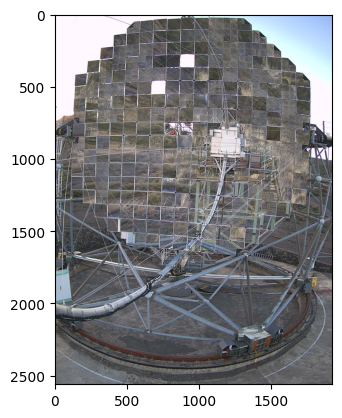

In [47]:
show_img(image_paths[25])

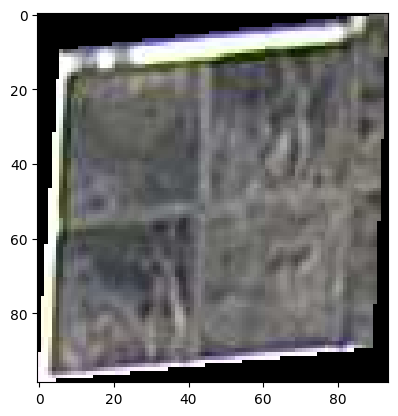

In [38]:
plt.imshow(m_list[65])

In [49]:
# --- 1. Model ---
model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
model.eval()

Using cache found in /home/pgliwny/.cache/torch/hub/facebookresearch_dinov2_main


DinoVisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv2d(3, 384, kernel_size=(14, 14), stride=(14, 14))
    (norm): Identity()
  )
  (blocks): ModuleList(
    (0-11): 12 x NestedTensorBlock(
      (norm1): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (attn): MemEffAttention(
        (qkv): Linear(in_features=384, out_features=1152, bias=True)
        (proj): Linear(in_features=384, out_features=384, bias=True)
        (proj_drop): Dropout(p=0.0, inplace=False)
      )
      (ls1): LayerScale()
      (drop_path1): Identity()
      (norm2): LayerNorm((384,), eps=1e-06, elementwise_affine=True)
      (mlp): Mlp(
        (fc1): Linear(in_features=384, out_features=1536, bias=True)
        (act): GELU(approximate='none')
        (fc2): Linear(in_features=1536, out_features=384, bias=True)
        (drop): Dropout(p=0.0, inplace=False)
      )
      (ls2): LayerScale()
      (drop_path2): Identity()
    )
  )
  (norm): LayerNorm((384,), eps=1e-06, elementwise_affi

In [50]:
transform = T.Compose([
    T.Resize((224, 224)),  # wielokrotność 14
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

# ---  Ekstrakcja embeddingów ---
def get_embedding(img):
    if isinstance(img, np.ndarray):
        img = Image.fromarray(img)
        
    x = transform(img).unsqueeze(0)
    with torch.no_grad():
        emb = model(x)  # shape: (1, 384)
    return emb.squeeze().numpy()

In [51]:
embeddings = np.array([get_embedding(img) for img in m_list])

Wyjaśniona wariancja: 18.0%


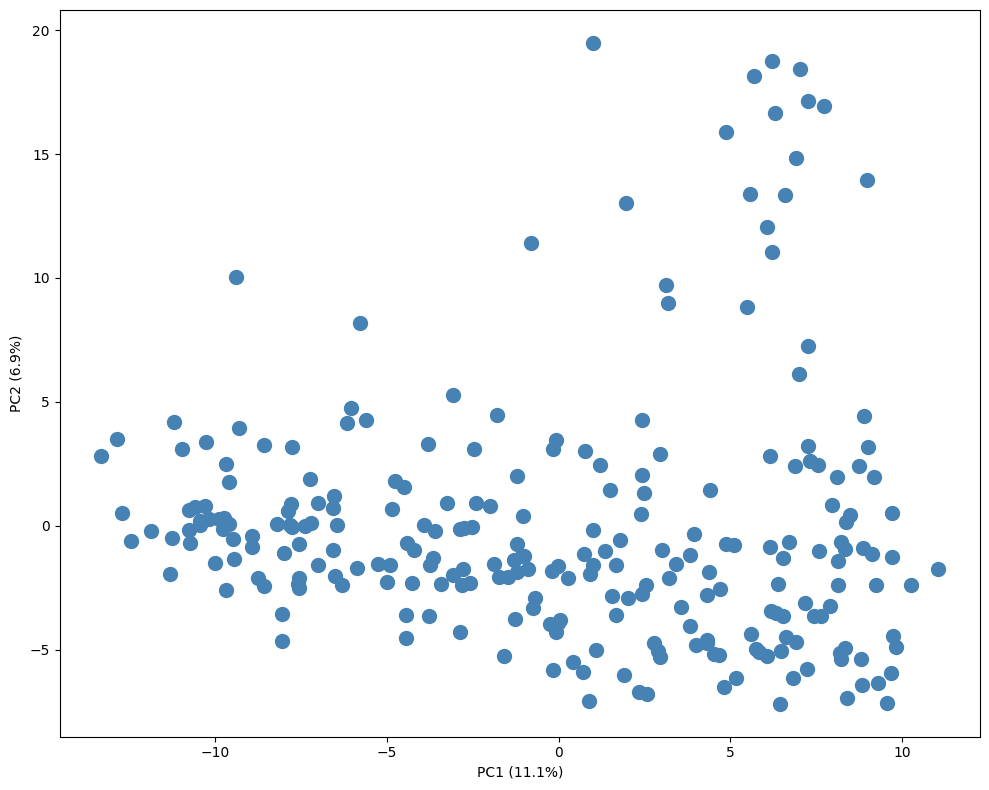

In [52]:
# Normalizacja (ważne!)
scaler = StandardScaler()
emb_scaled = scaler.fit_transform(embeddings)  # (N, 384)

# PCA → 2D
pca = PCA(n_components=2)
emb_2d = pca.fit_transform(emb_scaled)

print(f"Wyjaśniona wariancja: {pca.explained_variance_ratio_.sum():.1%}")

# Wykres
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1], s=100, c='steelblue')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.tight_layout()

In [56]:
# Na pełnych embeddingach (nie 2D!)
iso = IsolationForest(contamination=0.1, random_state=42)
outlier_labels = iso.fit_predict(emb_scaled)   # -1 = outlier
scores = iso.score_samples(emb_scaled)          # niższy = bardziej anomalny

outlier_idx = np.where(outlier_labels == -1)[0]
print(f"Potencjalne anomalie: {len(outlier_idx)} luster")
print(f"Indeksy: {outlier_idx}")

Potencjalne anomalie: 25 luster
Indeksy: [  8  19  23  31  40  57  83  89 106 121 123 124 127 128 133 136 144 150
 161 163 175 177 200 214 246]


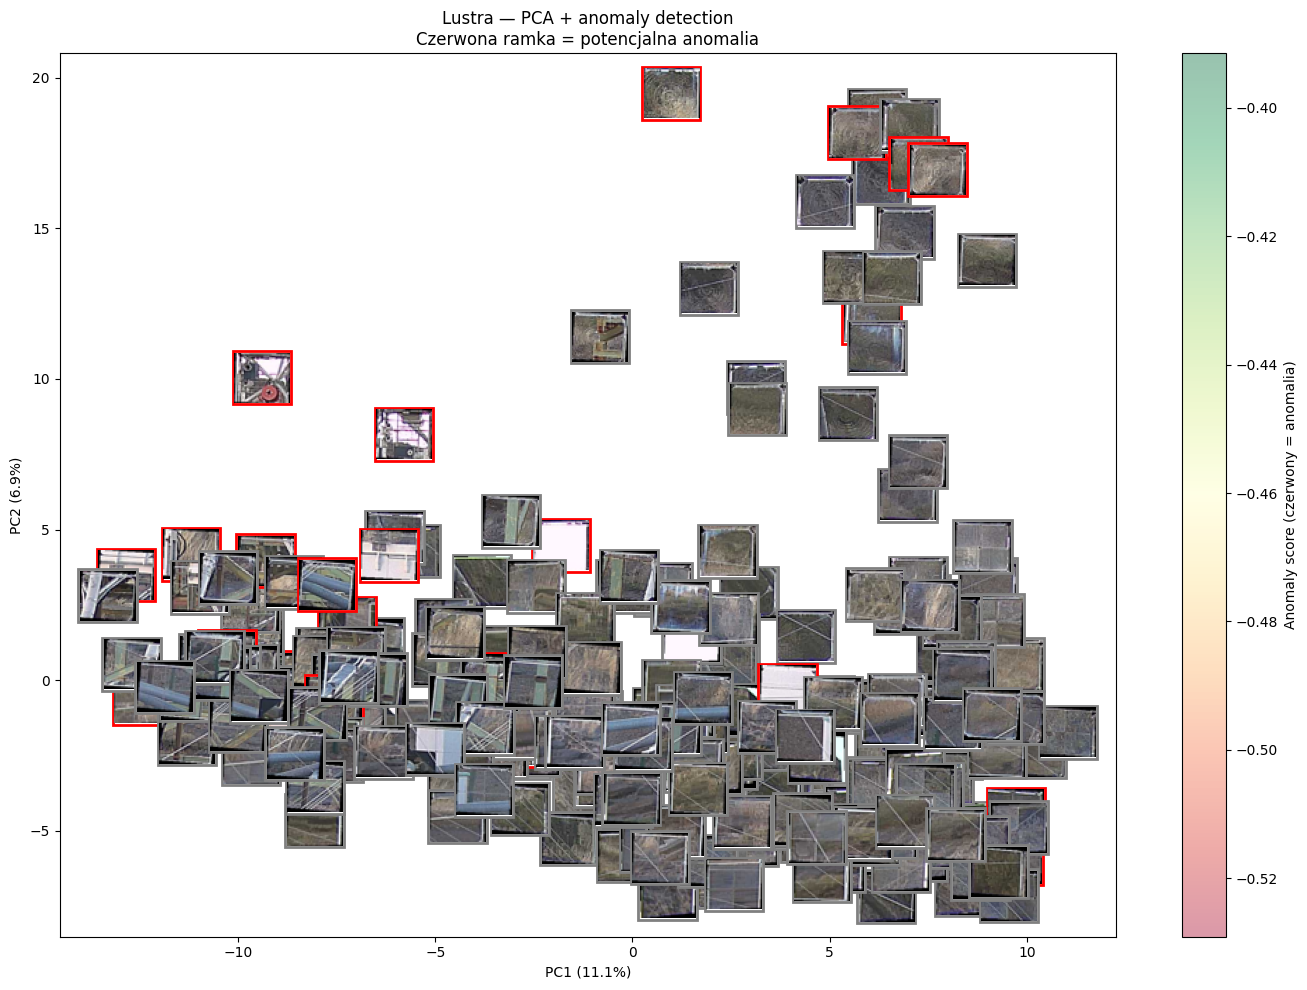

In [57]:
fig, ax = plt.subplots(figsize=(14, 10))

# Kolor = anomaly score
sc = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                c=scores, cmap='RdYlGn',
                s=60, alpha=0.4, zorder=1)
plt.colorbar(sc, label='Anomaly score (czerwony = anomalia)')

# Miniaturki luster bezpośrednio na wykresie
for i in range(len(m_list)):
    img_thumb = Image.fromarray(m_list[i]).resize((40, 36))
    
    # Ramka: czerwona dla outlierów, szara dla normalnych
    is_outlier = outlier_labels[i] == -1
    color = 'red' if is_outlier else 'gray'
    
    im = OffsetImage(np.array(img_thumb), zoom=1.0)
    ab = AnnotationBbox(im, (emb_2d[i, 0], emb_2d[i, 1]),
                        frameon=True, pad=0.1,
                        bboxprops=dict(edgecolor=color, linewidth=2))
    ax.add_artist(ab)

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%})')
ax.set_title('Lustra — PCA + anomaly detection\nCzerwona ramka = potencjalna anomalia')
plt.tight_layout()
plt.savefig('mirror_anomalies.png', dpi=150)
plt.show()

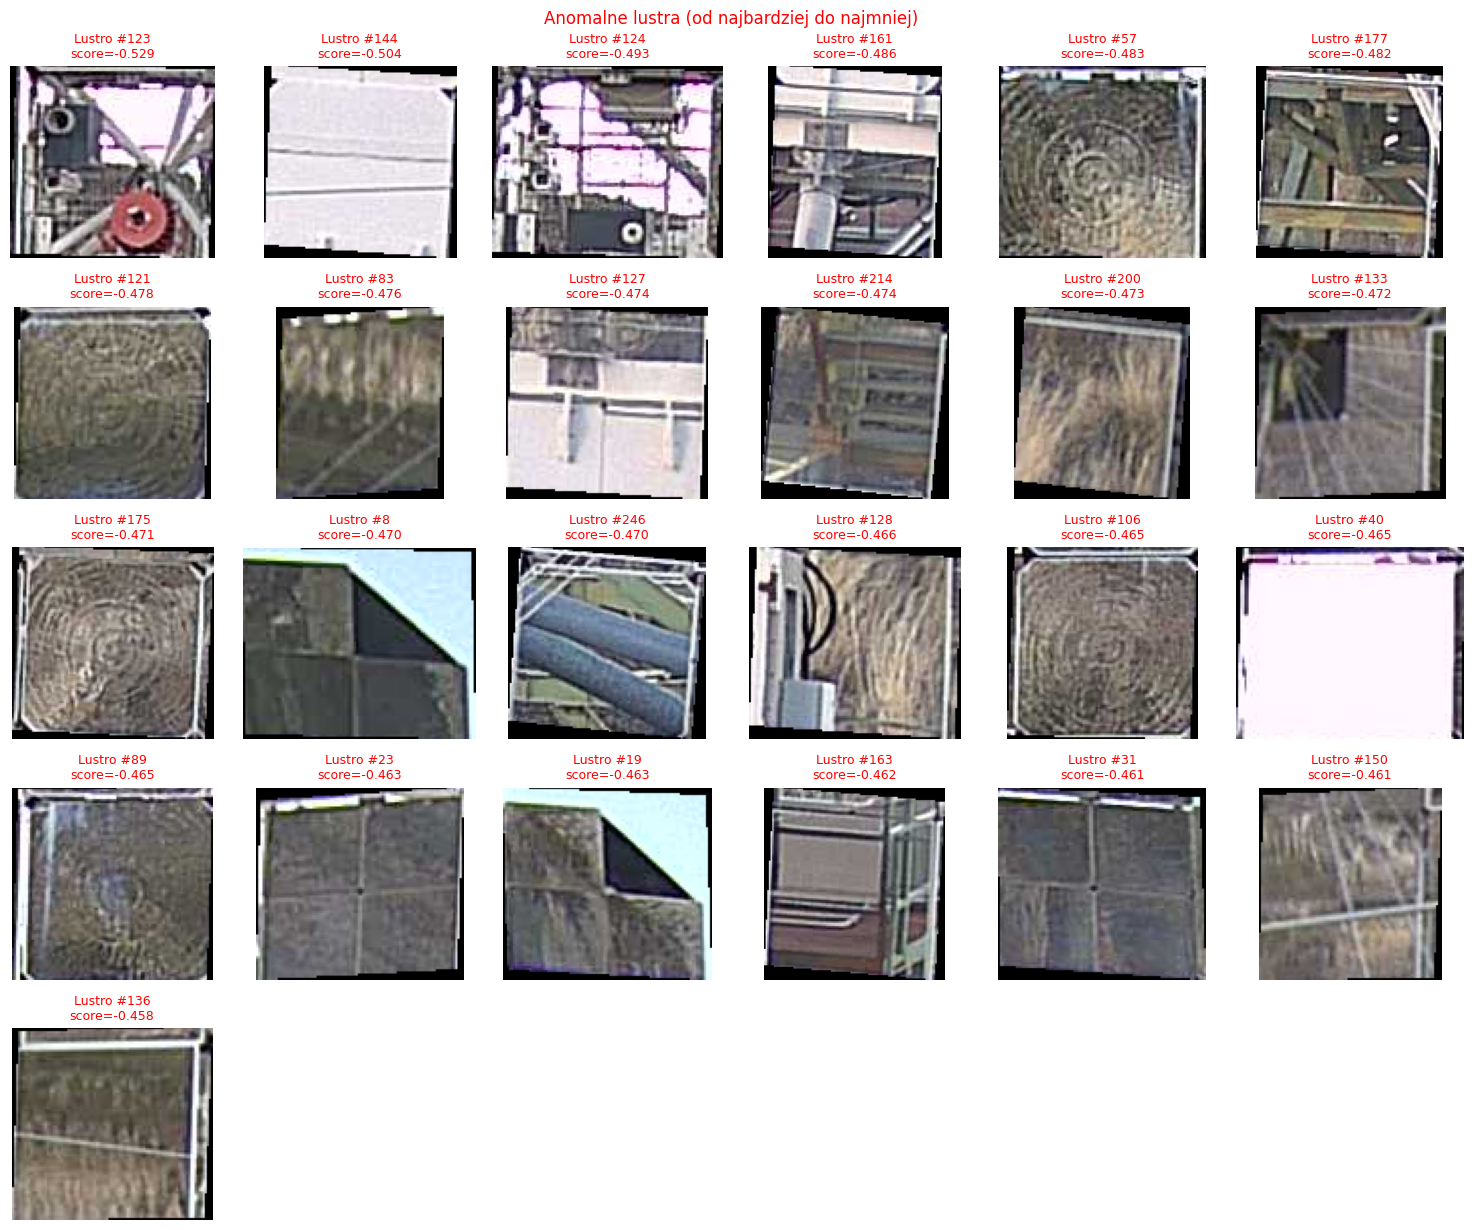

In [58]:
# Posortuj od najbardziej anomalnego
sorted_outliers = outlier_idx[np.argsort(scores[outlier_idx])]

n = len(sorted_outliers)
cols = min(n, 6)
rows = int(np.ceil(n / cols))

fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
axes = np.array(axes).flatten()

for ax, i in zip(axes, sorted_outliers):
    ax.imshow(m_list[i])
    ax.set_title(f'Lustro #{i}\nscore={scores[i]:.3f}', 
                 fontsize=9, color='red')
    ax.axis('off')

for ax in axes[n:]:
    ax.axis('off')

plt.suptitle('Anomalne lustra (od najbardziej do najmniej)', color='red')
plt.tight_layout()
plt.savefig('anomalous_mirrors.png', dpi=150)
plt.show()